# Final schedule analysis notebook

Ce notebook :

- lit **`data.dzn`** (données MiniZinc) ;
- lit **`solution.json`** (solution MiniZinc exportée en JSON, via `--output-mode json` ou un `output` JSON) ;
- reconstruit le tenseur `x_ijq` ;
- calcule et visualise toutes les métriques d'horaire que tu voulais, **une métrique par cellule** :
  - distribution du nombre d'employés au cours de la journée (avec semaine / weekend + heatmap jour × heure) ;
  - distribution des patients et des appels raccrochés ;
  - heures totales, heures supplémentaires, variance d'heures (par type d'employé) ;
  - nombre de jours consécutifs travaillés ;
  - changements brusques de quarts ;
  - nuits travaillées ;
  - répartition jour / soir / nuit / weekend ;
  - nombre de personnes par quart et par type ;
  - timeline horizontale (type Gantt) par employé.


## 1. Imports et fonctions utilitaires

In [1]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def slot_to_time_15(h):
    """Convertit un identifiant de tranche 15min (1..96) en 'HH:MM'."""
    total_minutes = (h - 1) * 15
    hh = total_minutes // 60
    mm = total_minutes % 60
    return f"{hh:02d}:{mm:02d}"

## 2. Lecture de `data.dzn` et reconstruction des paramètres

In [2]:
def parse_range(expr):
    """Parse '1..11' into python list [1,2,...,11]."""
    a, b = map(int, expr.split(".."))
    return list(range(a, b+1))

def parse_int_list(expr):
    """Parse '[1,2,3]' into [1,2,3]."""
    numbers = re.findall(r"-?\d+\.?\d*", expr)
    return [float(x) if "." in x else int(x) for x in numbers]

def load_data_from_dzn(path="data.dzn"):
    txt = open(path).read()
    data = {}

    # --- 1. Sets IR, IP, IE ---
    for key in ["IR","IP","IE"]:
        m = re.search(rf"{key}\s*=\s*([0-9]+\.\.[0-9]+)", txt)
        if not m:
            raise ValueError(f"Missing set {key} in dzn file")
        data[key] = parse_range(m.group(1))

    # Employees I
    data["I"] = data["IR"] + data["IP"] + data["IE"]

    # --- 2. IN = union of ranges ---
    m = re.search(r"IN\s*=\s*(.*?)\s*;", txt)
    if m:
        expr = m.group(1)
        parts = re.findall(r"(\d+\.\.\d+)", expr)
        IN = []
        for p in parts:
            IN += parse_range(p)
        data["IN"] = IN
    else:
        raise ValueError("Missing IN")

    # --- 3. horizon, J, W ---
    m = re.search(r"horizon\s*=\s*(\d+)", txt)
    data["horizon"] = int(m.group(1))

    data["J"] = list(range(1, data["horizon"]+1))
    data["W"] = list(range(1, data["horizon"]//7 + 1))

    # --- 4. JL, JW ---
    data["JL"] = [j for j in data["J"] if j % 7 == 1]
    data["JW"] = [j for j in data["J"] if (j % 7 == 0 or j % 7 == 6)]

    # --- 5. H ---
    m = re.search(r"H\s*=\s*([0-9]+\.\.[0-9]+)", txt)
    data["H"] = parse_range(m.group(1))

    # --- 6. debut_int, duree_int ---
    def extract_array(name):
        m = re.search(rf"{name}\s*=\s*\[(.*?)\];", txt, re.S)
        if not m:
            raise ValueError(f"Missing array {name}")
        return parse_int_list(m.group(1))

    data["debut_int"] = extract_array("debut_int")
    data["duree_int"] = extract_array("duree_int")

    # fin_int recomputed
    data["fin_int"] = [
        data["debut_int"][i] + data["duree_int"][i]
        for i in range(len(data["debut_int"]))
    ]

    # --- 7. Enumeration Q ---
    data["Q"] = ["q0_8","q7_8","q8_8","q11_5_8","q12_8","q14_8","q16_8","q8_12"]

    # --- 8. plages_quarts ---
    m = re.search(r"plages_quarts\s*=\s*\[(.*?)\];", txt, re.S)
    if not m:
        raise ValueError("Missing plages_quarts")
    blocks = m.group(1).split(",")
    plages = []
    for b in blocks:
        b = b.strip()
        if ".." in b:
            plages.append(parse_range(b))
    data["plages_quarts"] = plages

    # --- 9. a_hq ---
    H = data["H"]
    Q = data["Q"]
    a_hq = np.zeros((len(H), len(Q)), dtype=int)
    for q_idx,q in enumerate(Q):
        for h in H:
            if h in data["plages_quarts"][q_idx]:
                a_hq[h-1,q_idx] = 1
    data["a_hq"] = a_hq

    # --- 10. n_h ---
    data["n_h"] = np.array(extract_array("n_h"))

    # --- 11. T_max, c_barre ---
    IR = data["IR"]
    IP = data["IP"]
    IE = data["IE"]

    data["T_max"] = np.array([80.0]*len(IR) + [80.0]*len(IP) + [40.0]*len(IE))
    data["c_barre"] = np.array([24]*len(IR) + [20]*len(IP) + [10]*len(IE))

    # --- 12. Congés C[i] ---
    C = []
    for i in IR:
        if i == 4:
            C.append([1])
        elif i == 7:
            C.append([5])
        else:
            C.append([])
    data["C"] = C

    # --- 13. QN / QJ / QS ---
    data["QN"] = ["q0_8"]
    data["QJ"] = ["q7_8","q8_8","q11_5_8","q12_8","q14_8","q8_12"]
    data["QS"] = ["q16_8","q8_12"]

    # --- 14. patience et lmd ---
    m = re.search(r"\bpatience\s*=\s*(\d+)\s*;", txt)
    data["patience"] = int(m.group(1))

    m = re.search(r"\blmd\s*=\s*(\d+)\s*;", txt)
    data["lmd"] = int(m.group(1))

    # =====================================================
    # 15. POIDS DE L’OBJECTIF
    # =====================================================
    def parse_weight(name):
        m = re.search(rf"{name}\s*=\s*(\d+)\s*;", txt)
        if m:
            return int(m.group(1))
        else:
            raise ValueError(f"Poids manquant dans le .dzn : {name}")

    data["w_preferences"]          = parse_weight("w_preferences")
    data["w_equilibre_jour_soir"]  = parse_weight("w_equilibre_jour_soir")
    data["w_couverture"]           = parse_weight("w_couverture")
    data["w_heures_sup"]           = parse_weight("w_heures_sup")
    data["w_repos"]                = parse_weight("w_repos")

    return data


# Test
data = load_data_from_dzn("data.dzn")
print("Chargé ✔")
print("Poids =", data["w_preferences"], data["w_equilibre_jour_soir"],
      data["w_couverture"], data["w_heures_sup"], data["w_repos"])
print("Patience =", data["patience"])
print("lmd =", data["lmd"])


Chargé ✔
Poids = 200 1 50 1000 2000
Patience = 3
lmd = 2


## 3. Lecture de `solution.json` et reconstruction de `x_tensor`

In [3]:
# ============================
# Chargement solution JSON + Vérification
# ============================

def load_solution(path="solution.json"):
    """Charge un JSON MiniZinc et retourne (sol, x_tensor)."""
    with open(path, "r") as f:
        sol_raw = json.load(f)

    # Deux formats possibles :
    if isinstance(sol_raw, dict) and "solutions" in sol_raw:
        sol = sol_raw["solutions"][-1]
    else:
        sol = sol_raw

    # Extraction du vecteur brut
    x_raw = np.array(sol["x_ijq"], dtype=int)

    num_I = len(data["I"])
    num_J = len(data["J"])
    num_Q = len(data["Q"])

    expected = num_I * num_J * num_Q
    if x_raw.size != expected:
        raise ValueError(f"Taille inattendue de x_ijq: {x_raw.size}, attendu: {expected}")

    x_tensor = x_raw.reshape((num_I, num_J, num_Q))
    return sol, x_tensor


# -------------------------------------------------
# Charger solution
# -------------------------------------------------
sol_meta, x_tensor = load_solution("solution.json")

print("x_tensor reconstruit ✔ shape =", x_tensor.shape)
print("Clés disponibles dans la solution:", list(sol_meta.keys()))


# =====================================================
# Vérification s_jh et z_jh
# =====================================================

print("\n=== Vérification des variables MiniZinc → Python ===")

num_I = len(data["I"])
num_J = len(data["J"])
num_Q = len(data["Q"])
H = len(data["H"])

# ================
# Vérification x_ijq
# ================
x_raw = np.array(sol_meta["x_ijq"], dtype=int)
x_tensor_mzn = x_raw.reshape((num_I, num_J, num_Q))

if np.array_equal(x_tensor, x_tensor_mzn):
    print("✔ x_ijq : cohérent")
else:
    print("❌ x_ijq : incohérence détectée !")


# ================
# Vérification s_jh
# ================
s_raw = np.array(sol_meta["s_jh"], dtype=int)
s_mzn = s_raw.reshape((num_J, H))

# Recalcul Python
s_py = np.zeros((num_J, H), dtype=int)

for j_idx in range(num_J):
    for h_idx in range(H):
        total = 0
        for i_idx in range(num_I):
            for q_idx in range(num_Q):
                if data["a_hq"][h_idx, q_idx] == 1 and x_tensor[i_idx, j_idx, q_idx] == 1:
                    total += 1
        s_py[j_idx, h_idx] = total

if np.array_equal(s_mzn, s_py):
    print("✔ s_jh : cohérent")
else:
    print("❌ s_jh : incohérence détectée !")


# ================
# Vérification z_jh
# ================
z_raw = np.array(sol_meta["z_jh"], dtype=int)
z_mzn = z_raw.reshape((num_J, H))

# Recalcul Python
patience = data.get("patience", 3)
lmd = data.get("lmd", 2)
n_h = data["n_h"]

z_py = np.zeros((num_J, H), dtype=int)

for j_idx in range(num_J):
    for h_idx in range(H):
        if n_h[h_idx] > (patience+1) * lmd * s_py[j_idx, h_idx]:
            z_py[j_idx, h_idx] = 1

if np.array_equal(z_mzn, z_py):
    print("✔ z_jh : cohérent")
else:
    print("❌ z_jh : incohérence détectée !")

print("\n=== Vérification terminée ===")


x_tensor reconstruit ✔ shape = (86, 14, 8)
Clés disponibles dans la solution: ['objectif', 'score_preferences', 'penalite_equilibre_jour_soir', 'penalite_couverture', 'penalite_heures_sup', 'penalite_repos', 'x_ijq', 's_jh', 'z_jh']

=== Vérification des variables MiniZinc → Python ===
✔ x_ijq : cohérent
✔ s_jh : cohérent
✔ z_jh : cohérent

=== Vérification terminée ===


## 4. DataFrames de base : employés, quarts, planning

In [4]:
I = data['I']; J = data['J']; Q = data['Q']
H = data['H']
JW = data['JW']
IR = data['IR']; IP = data['IP']; IE = data['IE']

num_I, num_J, num_Q = x_tensor.shape

# Info employés
rows = []
for i in I:
    if i in IR:
        t = 'IR'
    elif i in IP:
        t = 'IP'
    else:
        t = 'IE'
    rows.append({'employee': i, 'type': t})
df_employees_info = pd.DataFrame(rows)

# Info quarts
pretty_q = {
    "q0_8":"00:00-08:00",
    "q7_8":"07:00-15:00",
    "q8_8":"08:00-16:00",
    "q11_5_8":"11:30-19:30",
    "q12_8":"12:00-20:00",
    "q14_8":"14:00-22:00",
    "q16_8":"16:00-00:00",
    "q8_12":"08:00-20:00"
}
DAY = set(['q7_8','q8_8','q11_5_8','q12_8','q14_8'])
NIGHT = set(['q0_8','q16_8'])
LONG = set(['q8_12'])

rows = []
for q in Q:
    if q in DAY:
        cat = 'DAY'
    elif q in NIGHT:
        cat = 'NIGHT'
    elif q in LONG:
        cat = 'LONG'
    else:
        cat = 'OTHER'
    rows.append({
        'shift': q,
        'shift_label': pretty_q[q],
        'start_int': data['debut_int'][Q.index(q)],
        'duration_int': data['duree_int'][Q.index(q)],
        'end_int': data['fin_int'][Q.index(q)],
        'category': cat
    })
df_shifts_info = pd.DataFrame(rows)

# Planning détaillé
rows = []
for i_idx,i in enumerate(I):
    t = df_employees_info.loc[df_employees_info['employee']==i, 'type'].iloc[0]
    for j_idx,j in enumerate(J):
        is_weekend = j in JW
        for q_idx,q in enumerate(Q):
            if x_tensor[i_idx,j_idx,q_idx] > 0:
                rows.append({
                    'employee': i,
                    'type': t,
                    'day': j,
                    'is_weekend': is_weekend,
                    'shift': q,
                    'shift_label': pretty_q[q]
                })
df_schedule = pd.DataFrame(rows)

print("df_employees_info:") 
display(df_employees_info.head())
print("\ndf_shifts_info:")
display(df_shifts_info.head())
print("\ndf_schedule:")
display(df_schedule.head())

df_employees_info:


,employee,type
0,1,IR
1,2,IR
2,3,IR
3,4,IR
4,5,IR



df_shifts_info:


,shift,shift_label,start_int,duration_int,end_int,category
0,q0_8,00:00-08:00,0,16,16,NIGHT
1,q7_8,07:00-15:00,14,16,30,DAY
2,q8_8,08:00-16:00,16,16,32,DAY
3,q11_5_8,11:30-19:30,23,16,39,DAY
4,q12_8,12:00-20:00,24,16,40,DAY



df_schedule:


,employee,type,day,is_weekend,shift,shift_label
0,1,IR,1,False,q12_8,12:00-20:00
1,1,IR,2,False,q8_8,08:00-16:00
2,1,IR,3,False,q8_8,08:00-16:00
3,1,IR,5,False,q8_8,08:00-16:00
4,1,IR,6,True,q8_8,08:00-16:00


## 5. Critère — Nombre d'employés au cours de la journée (semaine vs weekend + heatmap jour×heure)

df_staff_per_slot:


,day,is_weekend,hour_slot,num_employees
0,1,False,1,1
1,1,False,2,1
2,1,False,3,1
3,1,False,4,1
4,1,False,5,1


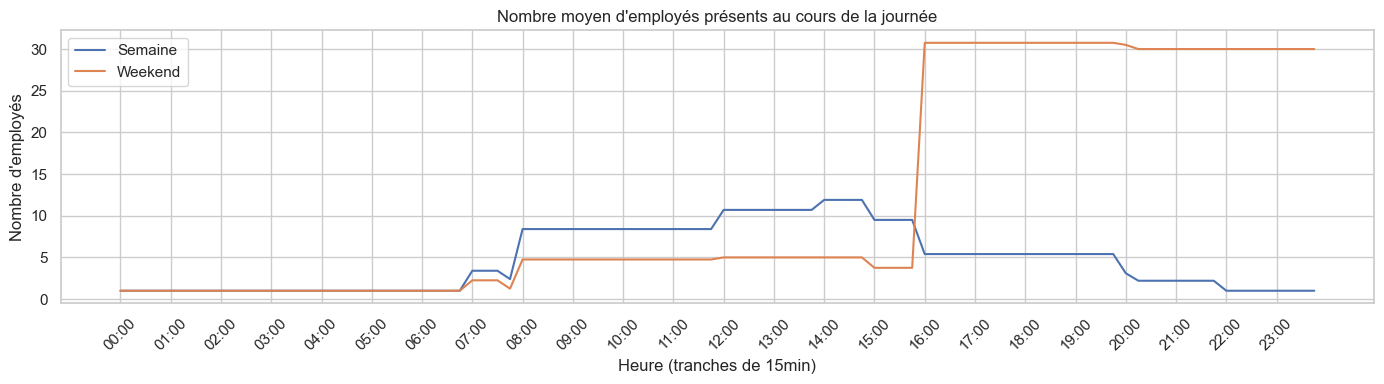

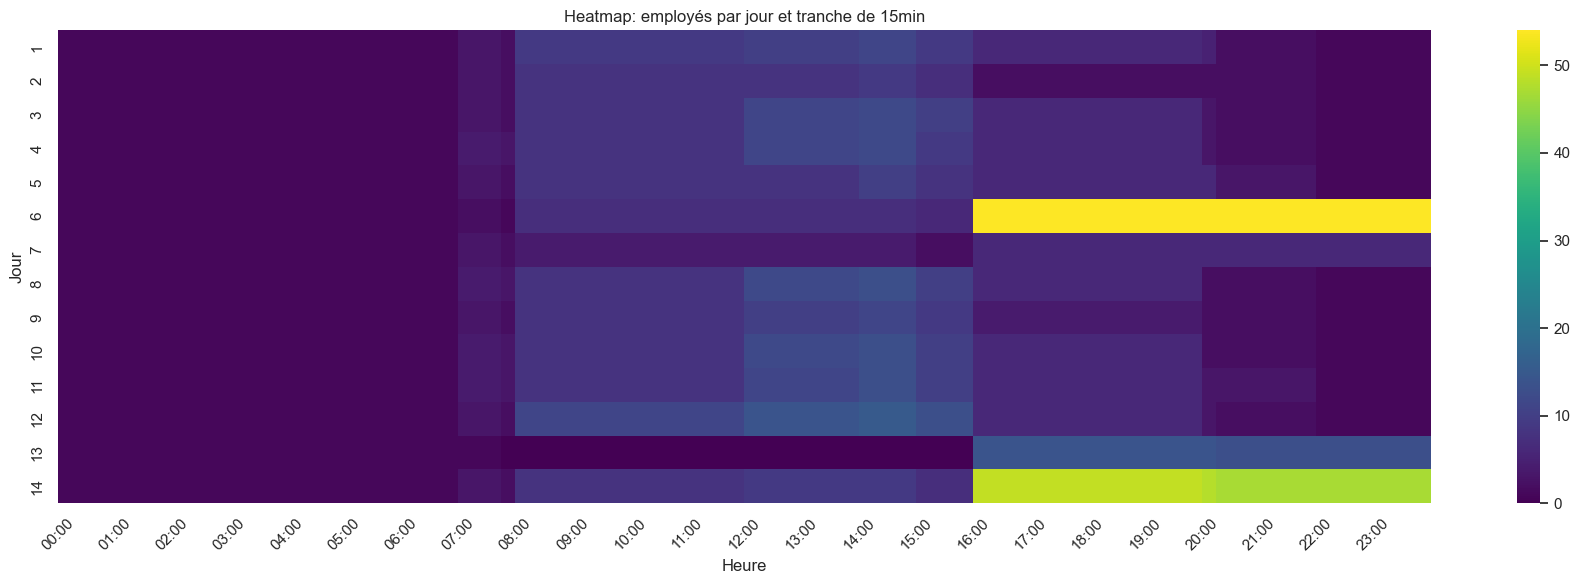

In [5]:
a_hq = data['a_hq']  # shape (|H|, |Q|)

records = []
for j_idx,j in enumerate(J):
    is_weekend = j in JW
    for h_idx,h in enumerate(H):
        staff = 0
        for i_idx in range(num_I):
            for q_idx in range(num_Q):
                if a_hq[h_idx,q_idx] == 1 and x_tensor[i_idx,j_idx,q_idx] > 0:
                    staff += 1
        records.append({
            'day': j,
            'is_weekend': is_weekend,
            'hour_slot': h,
            'num_employees': staff
        })

df_staff_per_slot = pd.DataFrame(records)
print("df_staff_per_slot:")
display(df_staff_per_slot.head())

# Moyenne semaine / weekend
weekday_curve = (
    df_staff_per_slot[~df_staff_per_slot['is_weekend']]
    .groupby('hour_slot')['num_employees']
    .mean()
)
weekend_curve = (
    df_staff_per_slot[df_staff_per_slot['is_weekend']]
    .groupby('hour_slot')['num_employees']
    .mean()
)

x_slots = list(H)
x_labels = [slot_to_time_15(h) for h in H]

plt.figure(figsize=(14,4))
plt.plot(x_slots, weekday_curve.values, label='Semaine')
plt.plot(x_slots, weekend_curve.values, label='Weekend')
plt.title("Nombre moyen d'employés présents au cours de la journée")
plt.xlabel("Heure (tranches de 15min)")
plt.ylabel("Nombre d'employés")
plt.xticks(ticks=range(1,97,4), labels=[slot_to_time_15(h) for h in range(1,97,4)], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Heatmap jour × heure
heat = df_staff_per_slot.pivot(index='day', columns='hour_slot', values='num_employees')
plt.figure(figsize=(18,6))
sns.heatmap(heat, cmap='viridis')
plt.title("Heatmap: employés par jour et tranche de 15min")
plt.xlabel("Heure")
plt.ylabel("Jour")
plt.xticks(ticks=range(0,96,4), labels=[slot_to_time_15(h) for h in range(1,97,4)], rotation=45)
plt.tight_layout()
plt.show()

## 6. Critère — Distribution du nombre de patients en attente / en appel au cours de la journée

df_patients_per_slot:


,day,hour_slot,patients,staff
0,1,1,3,1
1,1,2,3,1
2,1,3,3,1
3,1,4,4,1
4,1,5,2,1


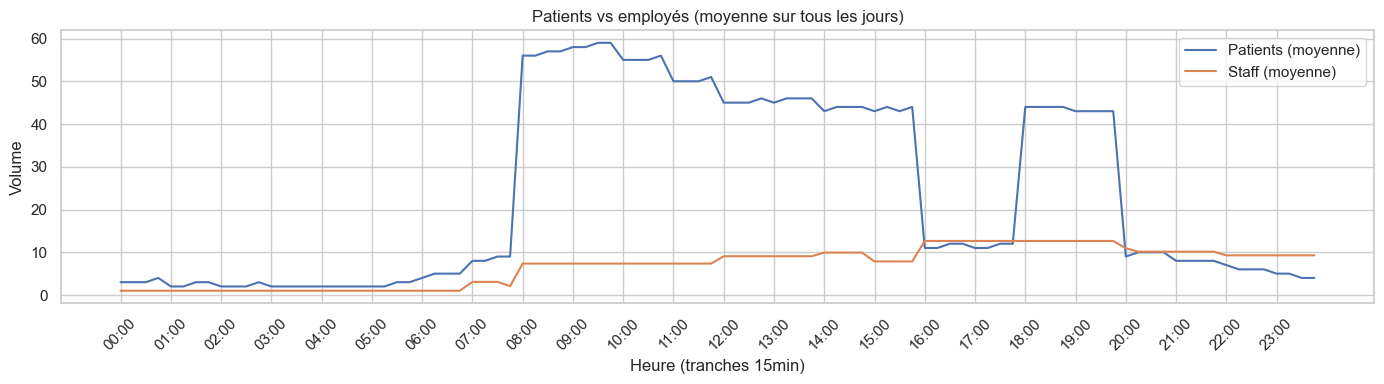

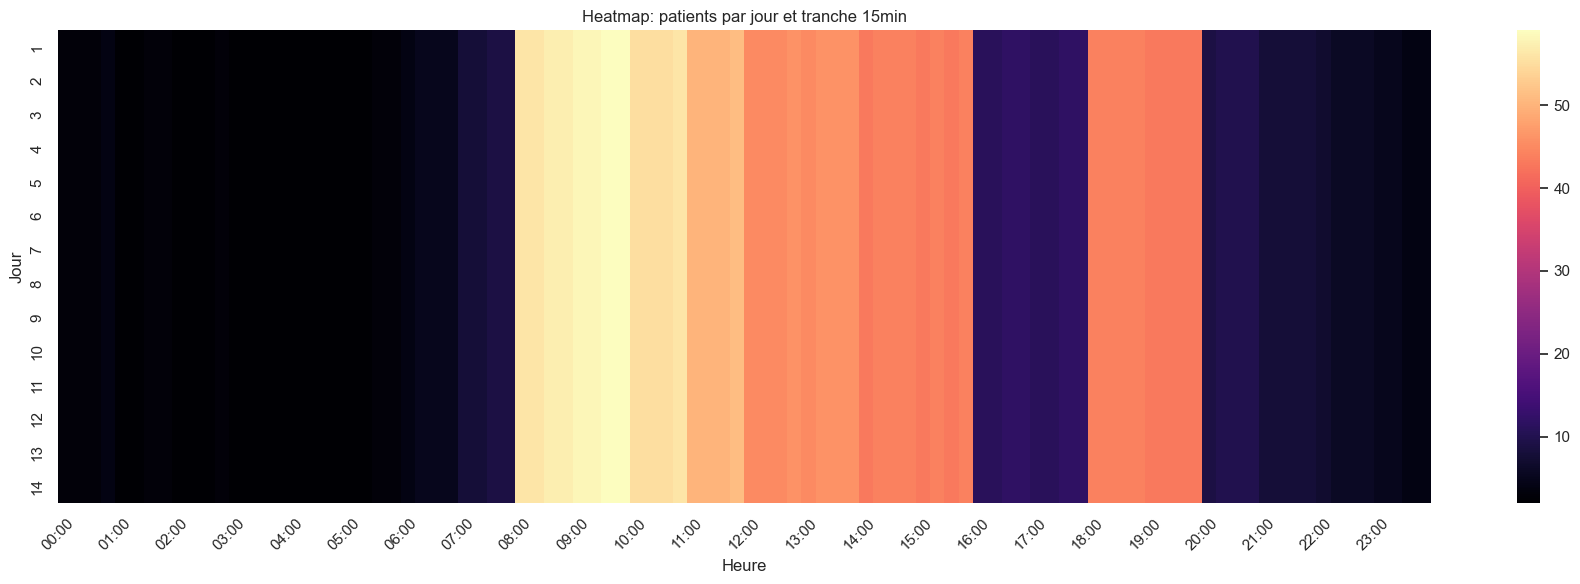

In [6]:
n_h = data['n_h']  # taille 96

records = []
for j in J:
    for h_idx,h in enumerate(H):
        patients = int(n_h[h_idx])
        staff = df_staff_per_slot.query("day == @j and hour_slot == @h")['num_employees'].iloc[0]
        records.append({
            'day': j,
            'hour_slot': h,
            'patients': patients,
            'staff': staff
        })

df_patients_per_slot = pd.DataFrame(records)
print("df_patients_per_slot:")
display(df_patients_per_slot.head())

mean_patients = df_patients_per_slot.groupby('hour_slot')['patients'].mean()
mean_staff = df_patients_per_slot.groupby('hour_slot')['staff'].mean()

plt.figure(figsize=(14,4))
plt.plot(H, mean_patients.values, label='Patients (moyenne)')
plt.plot(H, mean_staff.values, label='Staff (moyenne)')
plt.title("Patients vs employés (moyenne sur tous les jours)")
plt.xlabel("Heure (tranches 15min)")
plt.ylabel("Volume")
plt.xticks(ticks=range(1,97,4), labels=[slot_to_time_15(h) for h in range(1,97,4)], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Heatmap patients jour×heure
heat_pat = df_patients_per_slot.pivot(index='day', columns='hour_slot', values='patients')
plt.figure(figsize=(18,6))
sns.heatmap(heat_pat, cmap='magma')
plt.title("Heatmap: patients par jour et tranche 15min")
plt.xlabel("Heure")
plt.ylabel("Jour")
plt.xticks(ticks=range(0,96,4), labels=[slot_to_time_15(h) for h in range(1,97,4)], rotation=45)
plt.tight_layout()
plt.show()

## 7. Critère — Distribution du nombre d'appels raccrochés

df_hangups:


,day,hour_slot,patients,staff,hangups
0,1,1,3,1,0
1,1,2,3,1,0
2,1,3,3,1,0
3,1,4,4,1,0
4,1,5,2,1,0


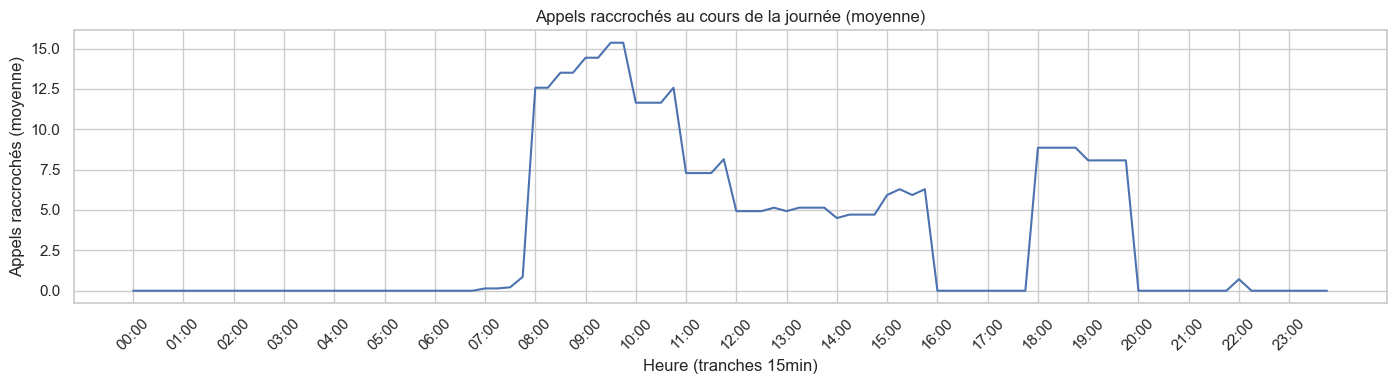

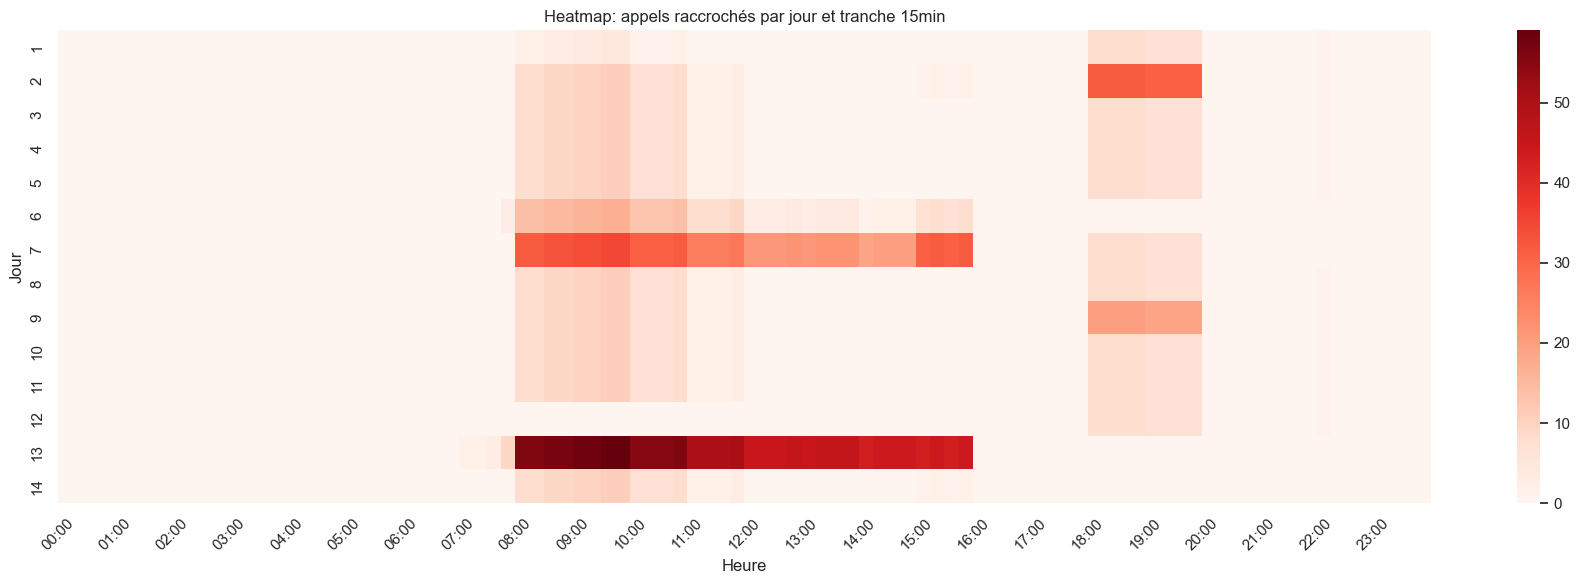

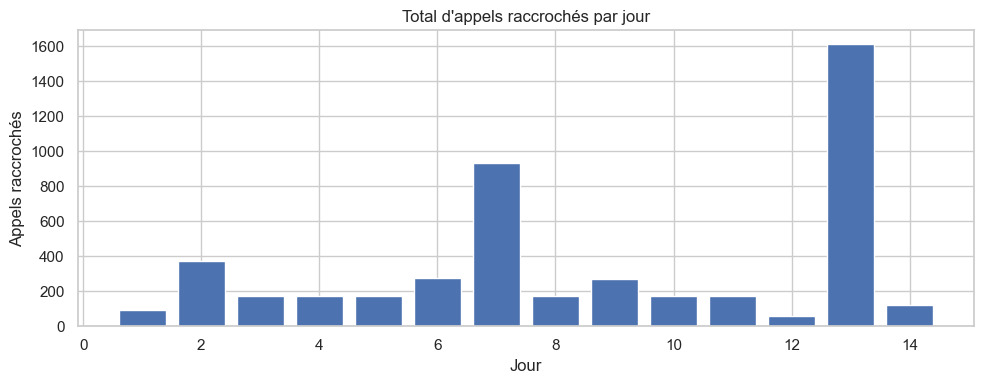

In [7]:
records = []
for j in J:
    for h_idx,h in enumerate(H):
        patients = int(n_h[h_idx])
        staff = df_staff_per_slot.query("day == @j and hour_slot == @h")['num_employees'].iloc[0]
        threshold = (data["patience"] * data["lmd"] * staff)
        hangups = max(0, patients - threshold)
        records.append({
            'day': j,
            'hour_slot': h,
            'patients': patients,
            'staff': staff,
            'hangups': hangups
        })

df_hangups = pd.DataFrame(records)
print("df_hangups:")
display(df_hangups.head())

mean_hangups = df_hangups.groupby('hour_slot')['hangups'].mean()

plt.figure(figsize=(14,4))
plt.plot(H, mean_hangups.values)
plt.title("Appels raccrochés au cours de la journée (moyenne)")
plt.xlabel("Heure (tranches 15min)")
plt.ylabel("Appels raccrochés (moyenne)")
plt.xticks(ticks=range(1,97,4), labels=[slot_to_time_15(h) for h in range(1,97,4)], rotation=45)
plt.tight_layout()
plt.show()

# Heatmap hangups
heat_h = df_hangups.pivot(index='day', columns='hour_slot', values='hangups')
plt.figure(figsize=(18,6))
sns.heatmap(heat_h, cmap='Reds')
plt.title("Heatmap: appels raccrochés par jour et tranche 15min")
plt.xlabel("Heure")
plt.ylabel("Jour")
plt.xticks(ticks=range(0,96,4), labels=[slot_to_time_15(h) for h in range(1,97,4)], rotation=45)
plt.tight_layout()
plt.show()

# Total par jour
daily_hangups = df_hangups.groupby('day')['hangups'].sum()
plt.figure(figsize=(10,4))
plt.bar(daily_hangups.index, daily_hangups.values)
plt.title("Total d'appels raccrochés par jour")
plt.xlabel("Jour")
plt.ylabel("Appels raccrochés")
plt.tight_layout()
plt.show()

## 8. Critère — Heures travaillées, overtime, variance des heures (par type d'employé)

df_employees_metrics (heures + OT):


,employee,type,total_hours,T_max,overtime
0,1,IR,80.0,80.0,0.0
1,2,IR,80.0,80.0,0.0
2,3,IR,80.0,80.0,0.0
3,4,IR,80.0,80.0,0.0
4,5,IR,80.0,80.0,0.0


Variance des heures par type:


,type,variance_hours
0,IE,0.258065
1,IP,0.000000
2,IR,0.000000


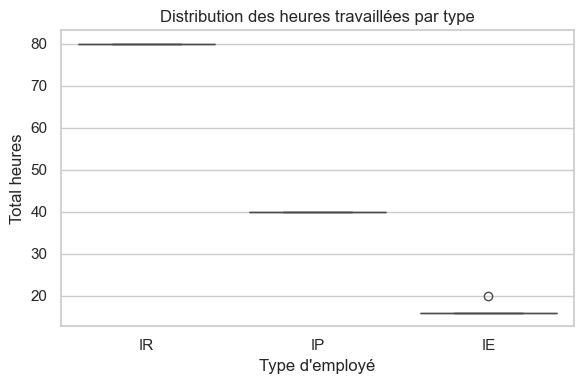

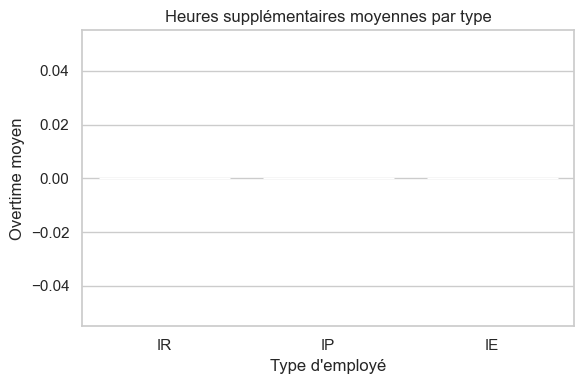

In [8]:
# Durée des quarts en heures (on divise duree_int par 2)
duree_hours = np.array([
    data['duree_int'][Q.index(q)] / 2.0
    for q in Q
])

hours_per_day = np.zeros((num_I, num_J))
for i_idx in range(num_I):
    for j_idx in range(num_J):
        hours_per_day[i_idx,j_idx] = (x_tensor[i_idx,j_idx,:] * duree_hours).sum()

total_hours = hours_per_day.sum(axis=1)
T_max = data['T_max']
overtime = np.maximum(0, total_hours - T_max)

df_employees_metrics = df_employees_info.copy()
df_employees_metrics['total_hours'] = total_hours
df_employees_metrics['T_max'] = T_max
df_employees_metrics['overtime'] = overtime

print("df_employees_metrics (heures + OT):")
display(df_employees_metrics.head())

# Variance par type
var_by_type = df_employees_metrics.groupby('type')['total_hours'].var().reset_index()
var_by_type.columns = ['type','variance_hours']
print("Variance des heures par type:")
display(var_by_type)

# Graphes
plt.figure(figsize=(6,4))
sns.boxplot(x='type', y='total_hours', data=df_employees_metrics)
plt.title("Distribution des heures travaillées par type")
plt.xlabel("Type d'employé")
plt.ylabel("Total heures")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x='type', y='overtime', data=df_employees_metrics, estimator=np.mean, errorbar=None)
plt.title("Heures supplémentaires moyennes par type")
plt.xlabel("Type d'employé")
plt.ylabel("Overtime moyen")
plt.tight_layout()
plt.show()


## 9. Critère — Nombre de jours consécutifs travaillés (par employé et par type)

Jours consécutifs par employé:


,employee,type,max_consec_days
0,1,IR,3
1,2,IR,2
2,3,IR,4
3,4,IR,4
4,5,IR,2


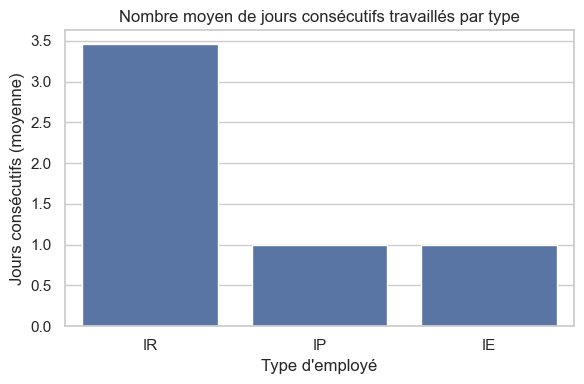

In [9]:
max_consec = np.zeros(num_I, dtype=int)
for i_idx in range(num_I):
    cur = 0
    best = 0
    for j_idx in range(num_J):
        worked = x_tensor[i_idx,j_idx,:].sum() > 0
        if worked:
            cur += 1
        else:
            best = max(best, cur)
            cur = 0
    best = max(best, cur)
    max_consec[i_idx] = best

df_employees_metrics['max_consec_days'] = max_consec

print("Jours consécutifs par employé:")
display(df_employees_metrics[['employee','type','max_consec_days']].head())

plt.figure(figsize=(6,4))
sns.barplot(x='type', y='max_consec_days', data=df_employees_metrics, estimator=np.mean, errorbar=None)
plt.title("Nombre moyen de jours consécutifs travaillés par type")
plt.xlabel("Type d'employé")
plt.ylabel("Jours consécutifs (moyenne)")
plt.tight_layout()
plt.show()

## 10. Critère — Changements brusques de quarts d'un jour à l'autre

Changements brusques de quart par employé:


,employee,type,abrupt_changes
0,1,IR,2
1,2,IR,2
2,3,IR,0
3,4,IR,2
4,5,IR,3


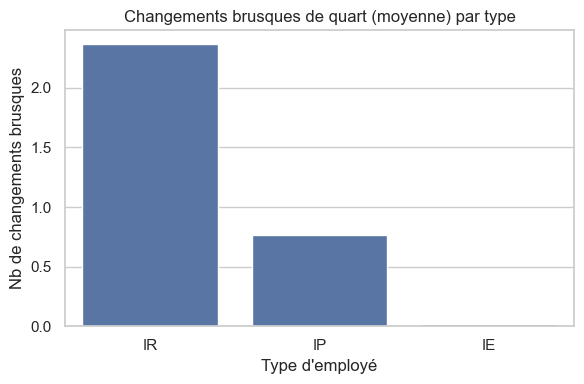

In [10]:
abrupt_changes = np.zeros(num_I, dtype=int)

for i_idx in range(num_I):
    prev_cat = None
    for j_idx in range(num_J):
        cats_present = set()
        for q_idx,q in enumerate(Q):
            if x_tensor[i_idx,j_idx,q_idx] > 0:
                if q in NIGHT:
                    cats_present.add('NIGHT')
                elif q in LONG:
                    cats_present.add('LONG')
                elif q in DAY:
                    cats_present.add('DAY')
        if 'NIGHT' in cats_present:
            cat = 'NIGHT'
        elif 'LONG' in cats_present:
            cat = 'LONG'
        elif 'DAY' in cats_present:
            cat = 'DAY'
        else:
            cat = None

        if prev_cat is not None and cat is not None and cat != prev_cat:
            abrupt_changes[i_idx] += 1
        if cat is not None:
            prev_cat = cat

df_employees_metrics['abrupt_changes'] = abrupt_changes

print("Changements brusques de quart par employé:")
display(df_employees_metrics[['employee','type','abrupt_changes']].head())

plt.figure(figsize=(6,4))
sns.barplot(x='type', y='abrupt_changes', data=df_employees_metrics, estimator=np.mean, errorbar=None)
plt.title("Changements brusques de quart (moyenne) par type")
plt.xlabel("Type d'employé")
plt.ylabel("Nb de changements brusques")
plt.tight_layout()
plt.show()

## 11. Critère — Nuits travaillées et répartition jour / soir / nuit / long / weekend

Répartition jour/nuit/long/weekend par employé:


,employee,type,day_shifts,night_shifts,long_shifts,weekend_shifts
0,1,IR,9,1,0,2
1,2,IR,4,0,4,2
2,3,IR,10,0,0,2
3,4,IR,6,1,2,2
4,5,IR,7,0,2,2


Moyennes par type:


,day_shifts,night_shifts,long_shifts,weekend_shifts
type,,,,
IE,0.000000,1.983871,0.016129,2.0
IP,4.384615,0.615385,0.000000,0.0
IR,7.454545,1.181818,0.909091,2.0


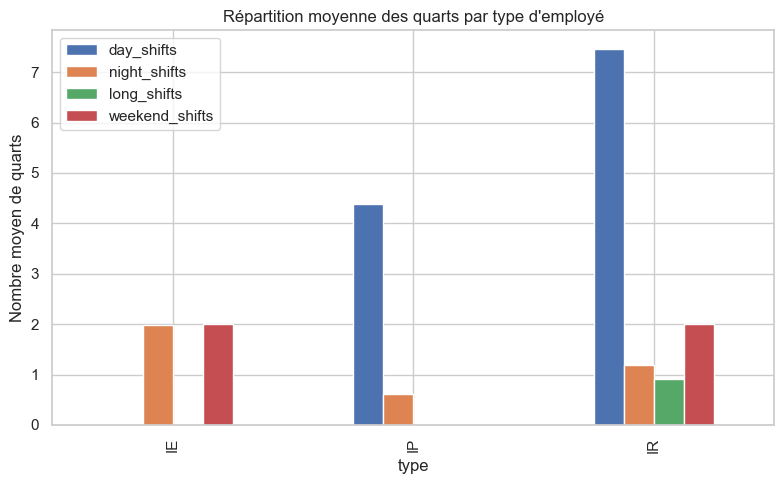

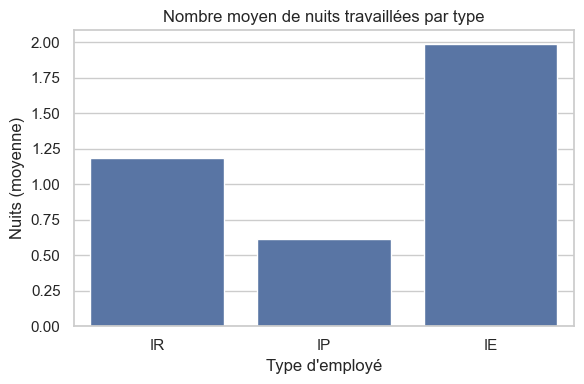

In [11]:
nights = np.zeros(num_I, dtype=int)
day_shifts = np.zeros(num_I, dtype=int)
night_shifts = np.zeros(num_I, dtype=int)
long_shifts = np.zeros(num_I, dtype=int)
weekend_shifts = np.zeros(num_I, dtype=int)

for i_idx,i in enumerate(I):
    for j_idx,j in enumerate(J):
        is_weekend = j in JW
        for q_idx,q in enumerate(Q):
            if x_tensor[i_idx,j_idx,q_idx] > 0:
                if q in DAY:
                    day_shifts[i_idx] += 1
                if q in NIGHT:
                    night_shifts[i_idx] += 1
                    nights[i_idx] += 1
                if q in LONG:
                    long_shifts[i_idx] += 1
                if is_weekend:
                    weekend_shifts[i_idx] += 1

df_employees_metrics['nights'] = nights
df_employees_metrics['day_shifts'] = day_shifts
df_employees_metrics['night_shifts'] = night_shifts
df_employees_metrics['long_shifts'] = long_shifts
df_employees_metrics['weekend_shifts'] = weekend_shifts

print("Répartition jour/nuit/long/weekend par employé:")
display(df_employees_metrics[['employee','type','day_shifts','night_shifts','long_shifts','weekend_shifts']].head())

# Graphes agrégés par type
agg = df_employees_metrics.groupby('type')[['day_shifts','night_shifts','long_shifts','weekend_shifts']].mean()
print("Moyennes par type:")
display(agg)

agg.plot(kind='bar', figsize=(8,5))
plt.title("Répartition moyenne des quarts par type d'employé")
plt.ylabel("Nombre moyen de quarts")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x='type', y='nights', data=df_employees_metrics, estimator=np.mean, errorbar=None)
plt.title("Nombre moyen de nuits travaillées par type")
plt.xlabel("Type d'employé")
plt.ylabel("Nuits (moyenne)")
plt.tight_layout()
plt.show()

## 12. Critère — Nombre d'employés par quart et par type

df_shifts_count:


type,shift,IE,IP,IR,shift_label
0,q0_8,3,3,2,00:00-08:00
4,q7_8,0,8,10,07:00-15:00
6,q8_8,0,12,11,08:00-16:00
5,q8_12,1,0,4,08:00-20:00
1,q12_8,0,10,7,12:00-20:00
2,q14_8,0,5,3,14:00-22:00
3,q16_8,62,3,5,16:00-00:00


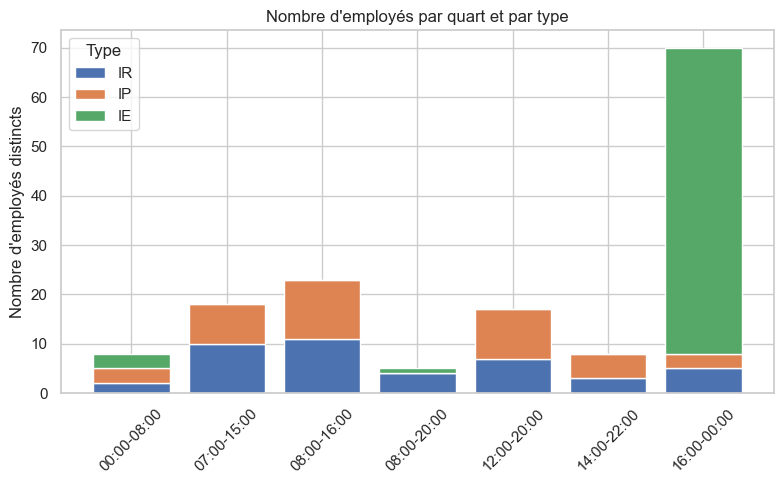

In [12]:
df_shifts_count = (
    df_schedule
    .groupby(['shift','type'])['employee']
    .nunique()
    .unstack(fill_value=0)
    .reset_index()
)

df_shifts_count['shift_label'] = df_shifts_count['shift'].map(pretty_q)
df_shifts_count = df_shifts_count.sort_values('shift_label')

print("df_shifts_count:")
display(df_shifts_count)

plt.figure(figsize=(8,5))
bottom = np.zeros(len(df_shifts_count))
for col in ['IR','IP','IE']:
    if col in df_shifts_count.columns:
        plt.bar(df_shifts_count['shift_label'], df_shifts_count[col], bottom=bottom, label=col)
        bottom += df_shifts_count[col].values
plt.title("Nombre d'employés par quart et par type")
plt.ylabel("Nombre d'employés distincts")
plt.xticks(rotation=45)
plt.legend(title="Type")
plt.tight_layout()
plt.show()

## 13. Critère — Timeline horizontale des shifts par employé (Gantt)

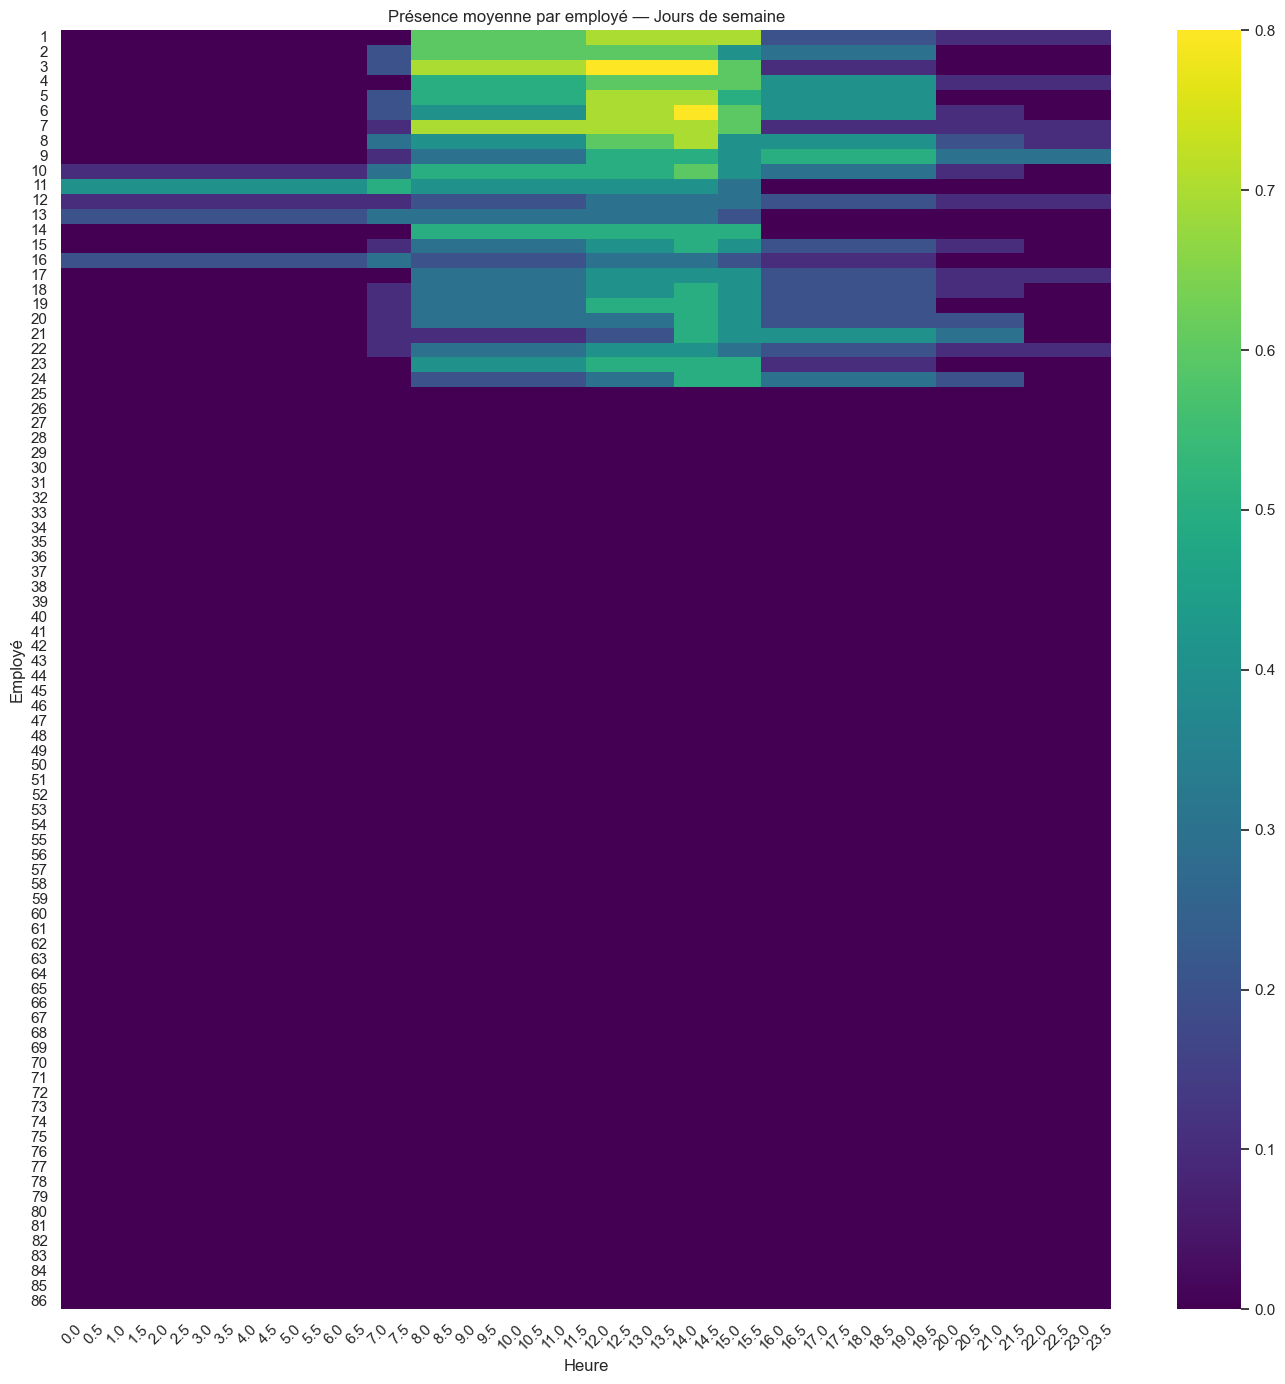

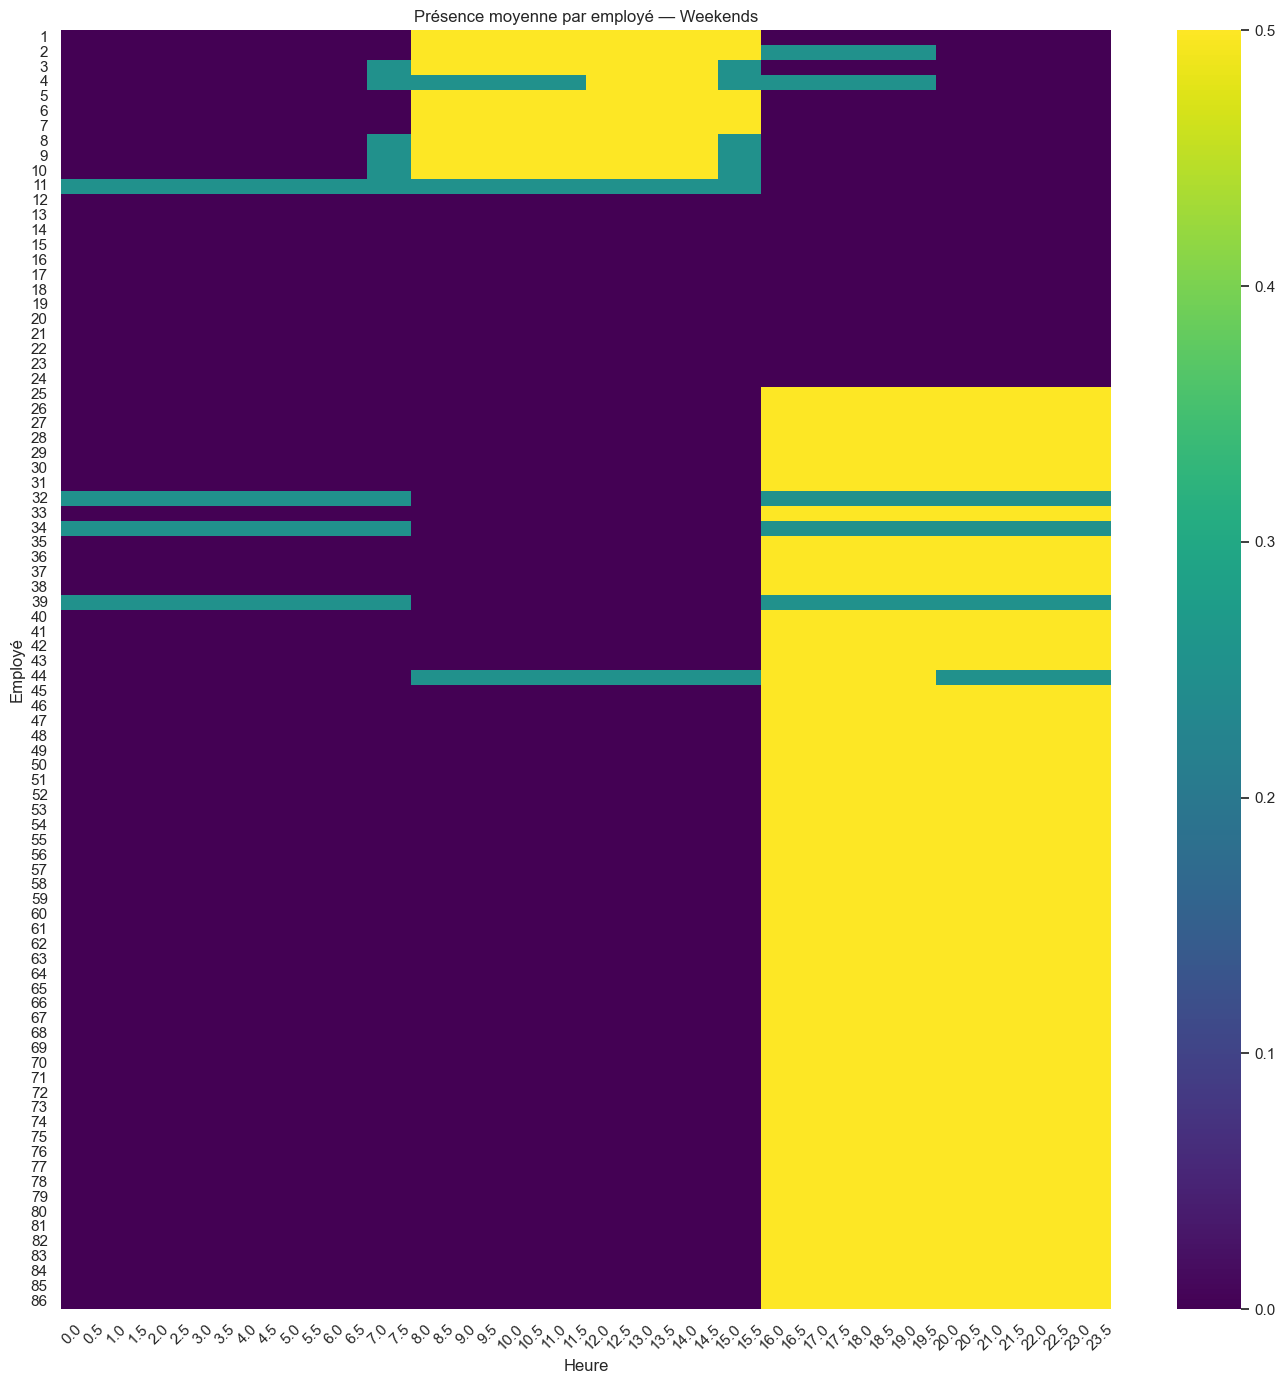

In [13]:
# ============================================================
# HEATMAP DE PRÉSENCE PAR EMPLOYÉ (MOYENNE HEBDOMADAIRE)
# ============================================================

num_I, num_J, num_Q = x_tensor.shape
HOURS = np.arange(0, 24, 0.5)  # tranches de 30 minutes = 48 slots
num_H = len(HOURS)

# Prépare une matrice vide : employés × heures × 2 (0=semaine, 1=weekend)
presence_week = np.zeros((num_I, num_H))
presence_weekend = np.zeros((num_I, num_H))

# On reconstruit les slots horaires travaillés
for i_idx, i in enumerate(I):
    for j_idx, j in enumerate(J):
        is_weekend = j in JW

        # Pour chaque quart attribué ce jour-là :
        for q_idx, q in enumerate(Q):
            if x_tensor[i_idx, j_idx, q_idx] > 0:
                start = data["debut_int"][q_idx] / 2.0
                end   = data["fin_int"][q_idx]   / 2.0

                # on marque la présence sur les tranches horaires concernées
                for h_idx, h in enumerate(HOURS):
                    if start <= h < end:
                        if is_weekend:
                            presence_weekend[i_idx, h_idx] += 1
                        else:
                            presence_week[i_idx, h_idx] += 1

# On normalise par nombre de jours de chaque type
num_weekdays = len([j for j in J if j not in JW])
num_weekends = len([j for j in J if j in JW])

presence_week   /= max(1, num_weekdays)
presence_weekend /= max(1, num_weekends)

# ============================
# Heatmap semaine
# ============================
plt.figure(figsize=(14, 14))
sns.heatmap(
    presence_week,
    cmap="viridis",
    xticklabels=HOURS,
    yticklabels=I
)
plt.title("Présence moyenne par employé — Jours de semaine")
plt.xlabel("Heure")
plt.ylabel("Employé")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================
# Heatmap weekend
# ============================
plt.figure(figsize=(14, 14))
sns.heatmap(
    presence_weekend,
    cmap="viridis",
    xticklabels=HOURS,
    yticklabels=I
)
plt.title("Présence moyenne par employé — Weekends")
plt.xlabel("Heure")
plt.ylabel("Employé")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


📊 Impact des composantes de l’objectif :


,Terme,Valeur brute,Poids,Contribution absolue,Contribution (%)
0,Préférences,5680,200,1136000,53.78
1,Équilibre jour/soir,-9,1,-9,0.00
2,Couverture,-89,50,-4450,0.21
3,Heures sup,-880,1000,-880000,41.66
4,Repos,-46,2000,-92000,4.36


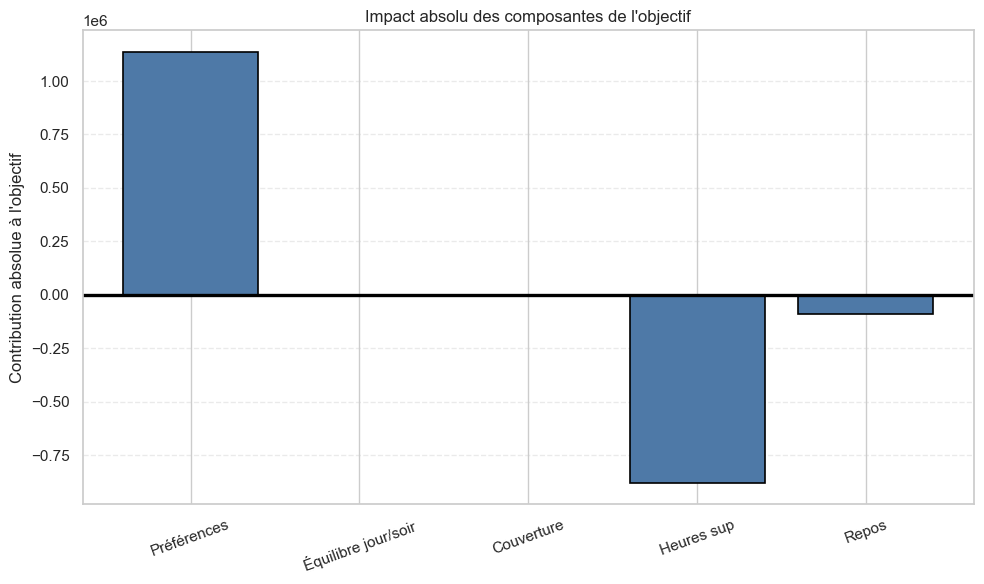

C:\Users\sacma\AppData\Local\Temp\ipykernel_42928\1533846750.py:130: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


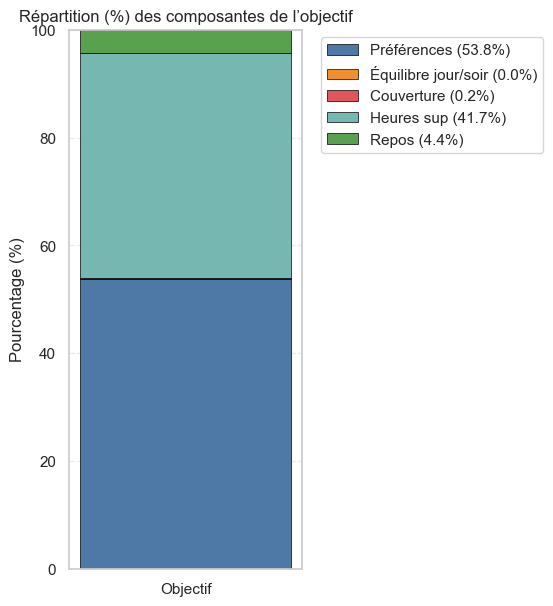

In [14]:
# =========================================================
# ANALYSE : CONTRIBUTION DES POIDS DANS L’OBJECTIF
# =========================================================

# 1) Vérification
for key in [
    "score_preferences",
    "penalite_equilibre_jour_soir",
    "penalite_couverture",
    "penalite_heures_sup",
    "penalite_repos"
]:
    if key not in sol_meta:
        raise ValueError(f"⚠️ Terme manquant dans sol_meta : {key}")

for key in [
    "w_preferences",
    "w_equilibre_jour_soir",
    "w_couverture",
    "w_heures_sup",
    "w_repos"
]:
    if key not in data:
        raise ValueError(f"⚠️ Poids manquant dans data : {key}")


# 2) Extraction des valeurs et poids
terms = {
    "Préférences": sol_meta["score_preferences"],
    "Équilibre jour/soir": sol_meta["penalite_equilibre_jour_soir"],
    "Couverture": sol_meta["penalite_couverture"],
    "Heures sup": sol_meta["penalite_heures_sup"],
    "Repos": sol_meta["penalite_repos"],
}

weights = {
    "Préférences": data["w_preferences"],
    "Équilibre jour/soir": data["w_equilibre_jour_soir"],
    "Couverture": data["w_couverture"],
    "Heures sup": data["w_heures_sup"],
    "Repos": data["w_repos"],
}

contrib = {k: terms[k] * weights[k] for k in terms}


# 3) Pourcentages (avec valeurs absolues)
total_abs = sum(abs(v) for v in contrib.values())
percent = {k: 100 * abs(contrib[k]) / total_abs for k in contrib}


# 4) Dataframe récapitulatif
df_contrib = pd.DataFrame({
    "Terme": list(terms.keys()),
    "Valeur brute": list(terms.values()),
    "Poids": list(weights.values()),
    "Contribution absolue": list(contrib.values()),
    "Contribution (%)": [round(percent[k], 2) for k in percent],
})

print("📊 Impact des composantes de l’objectif :")
display(df_contrib)

# =========================================================
# GRAPHIQUE 1 : CONTRIBUTIONS ABSOLUES (verticales)
# + grosse ligne horizontale à zéro
# =========================================================

plt.figure(figsize=(10, 6))

# Barres verticales
plt.bar(
    df_contrib["Terme"],
    df_contrib["Contribution absolue"],
    color="#4e79a7",
    edgecolor="black",
    linewidth=1.2
)

# ➤ Grosse ligne à 0
plt.axhline(0, color="black", linewidth=2.4)

plt.ylabel("Contribution absolue à l'objectif")
plt.title("Impact absolu des composantes de l'objectif")

# Rotation légère pour lisibilité
plt.xticks(rotation=20)

# Grille fine sur l’axe Y
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# =========================================================
# GRAPHIQUE 2 : JAUGE VERTICALE (barre 100% empilée)
# =========================================================

# Couleurs pour chaque terme
colors = {
"Préférences": "#4e79a7",
"Équilibre jour/soir": "#f28e2c",
"Couverture": "#e15759",
"Heures sup": "#76b7b2",
"Repos": "#59a14f",
}

plt.figure(figsize=(3,7))

# Point de départ
bottom = 0
for k in terms.keys():
    plt.bar(
        x=["Objectif"],
        height=[percent[k]],
        bottom=[bottom],
        color=colors[k],
        edgecolor="black",
        linewidth=0.5,
        label=f"{k} ({percent[k]:.1f}%)"
    )
    bottom += percent[k]

plt.ylabel("Pourcentage (%)")
plt.title("Répartition (%) des composantes de l’objectif")
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
